### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


## Explore the Dataset

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv("grades_crpt.csv")
print(f"Dataset shape: {df.shape[0]} students × {df.shape[1]} columns")
df.head(10)

Dataset shape: 86 students × 9 columns


,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005
5,100.0,92.9,100.0,96.2,NaN,80.0,110.5,97.5,U006
6,95.8,64.3,63.0,175.8,85.0,76.0,83.8,64.4,U007
7,168.9,100.0,40.0,95.0,100.0,100.0,NaN,40.6,U008
8,83.3,85.7,50.0,90.0,NaN,80.0,87.5,51.9,U009
9,129.9,76.8,-5.3,93.8,100.0,90.0,12.2,65.3,U010


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     str    
dtypes: float64(8), str(1)
memory usage: 6.2 KB


In [35]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


- The dataset has 86 students with 7 assignment grades (A1–A7) and a Final Exam grade
- df.describe() reveals minimum values below 0 and maximums well above 100 in several columns
- Final_Exam is the only column with no missing values
- Every assignment column has missing values; A1, A2, A3, and A5 are missing the most
- The user_id column is an identifier and will be excluded from numeric analyses

## Check the Correlations

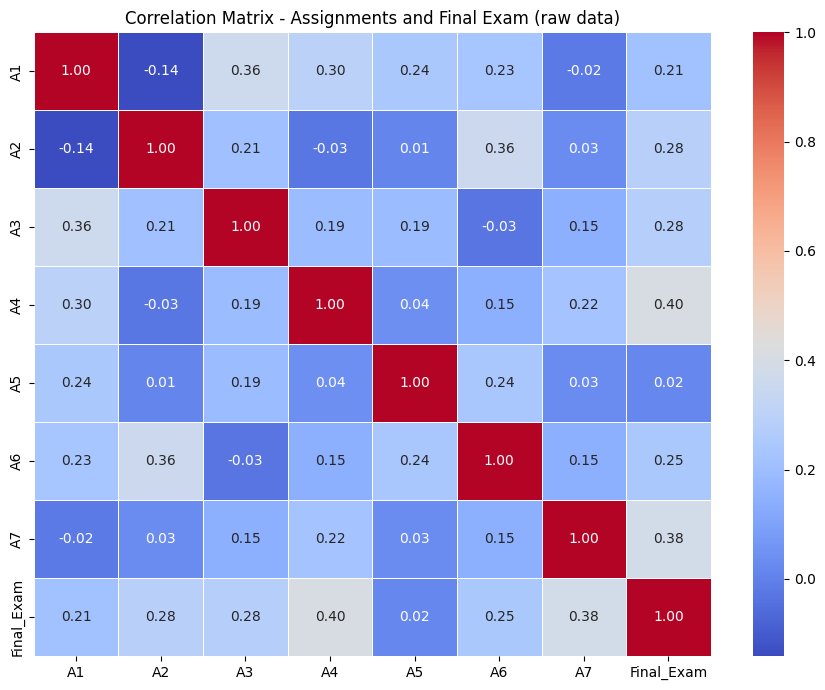

In [36]:
grade_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']

corr = df[grade_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix - Assignments and Final Exam (raw data)')
plt.tight_layout()
plt.show()

Pearson r with Final Exam:
A4    0.403
A7    0.381
A2    0.285
A3    0.278
A6    0.246
A1    0.213
A5    0.018

Top 2 assignments: A4  (r=0.403)  and  A7  (r=0.381)


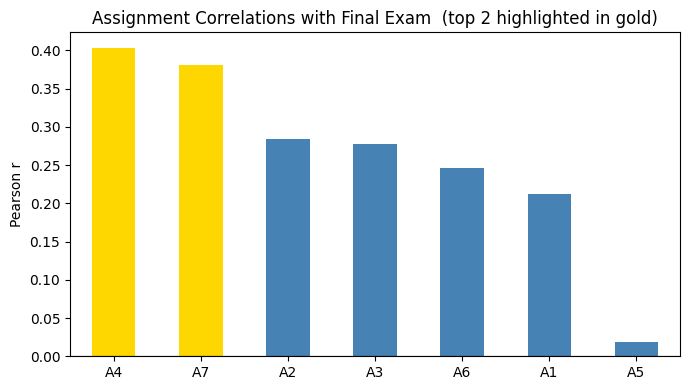

In [37]:
final_corr = corr['Final_Exam'].drop('Final_Exam').sort_values(ascending=False)

print("Pearson r with Final Exam:")
print(final_corr.round(3).to_string())

top2 = final_corr.head(2).index.tolist()
col1, col2 = top2[0], top2[1]
print(f"\nTop 2 assignments: {col1}  (r={final_corr[col1]:.3f})  and  {col2}  (r={final_corr[col2]:.3f})")

colors = ['gold' if c in top2 else 'steelblue' for c in final_corr.index]
plt.figure(figsize=(7, 4))
final_corr.plot(kind='bar', color=colors)
plt.title('Assignment Correlations with Final Exam  (top 2 highlighted in gold)')
plt.ylabel('Pearson r')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The two highlighted assignments have the highest positive correlation with the Final Exam.

- A higher Pearson r means the assignment grade changes in step with the Final Exam grade
    - Students who do well on this assignment also tend to do well on the exam
- Because the correlations are computed on raw (uncleaned) data, outliers add noise and may depress the true correlations
    - The relative ranking is still a reliable guide: if an assignment correlates well even in noisy data, it is a genuinely strong predictor

## Check for Missing Values

            Count  Percent %
A1             29       33.7
A2             25       29.1
A3             24       27.9
A4              9       10.5
A5             25       29.1
A6             19       22.1
A7             10       11.6
Final_Exam      0        0.0


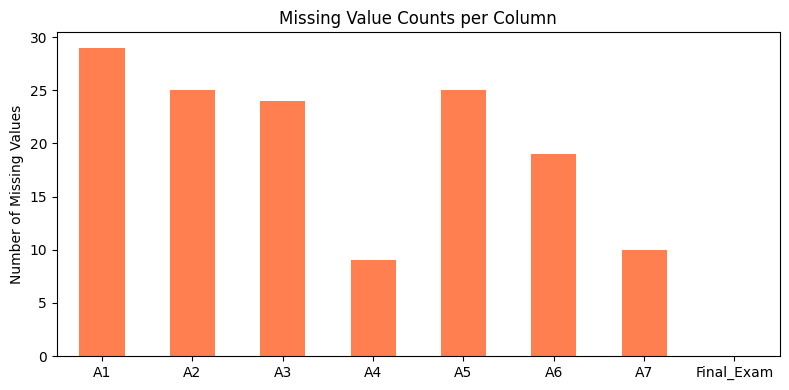

In [38]:
missing = df[grade_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

summary = pd.DataFrame({'Count': missing, 'Percent %': missing_pct})
print(summary)

plt.figure(figsize=(8, 4))
missing.plot(kind='bar', color='coral')
plt.title('Missing Value Counts per Column')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- A1, A2, A3, and A5 each miss ~25–29 rows (roughly 29–34% of the dataset)
- A4 and A7 have the fewest missing entries (~9–10 rows)
- Final_Exam has no missing values

The high missing rates in some columns most likely reflect students who did not submit those assignments

## Handle the Missing Values

In [39]:
df_drop = df.dropna(subset=[col1, col2]).copy()

print(f"Drop rows with NaN in {col1} or {col2}")
print(f"  Rows retained : {len(df_drop)} / {len(df)}")
print(f"  {col1:3s}  mean={df_drop[col1].mean():.2f}  std={df_drop[col1].std():.2f}")
print(f"  {col2:3s}  mean={df_drop[col2].mean():.2f}  std={df_drop[col2].std():.2f}")
print(f"  Corr {col1}-Final_Exam : {df_drop[[col1,'Final_Exam']].corr().iloc[0,1]:.3f}")
print(f"  Corr {col2}-Final_Exam : {df_drop[[col2,'Final_Exam']].corr().iloc[0,1]:.3f}")

Drop rows with NaN in A4 or A7
  Rows retained : 70 / 86
  A4   mean=81.71  std=37.69
  A7   mean=76.03  std=24.73
  Corr A4-Final_Exam : 0.347
  Corr A7-Final_Exam : 0.324


In [40]:
df_mean = df.copy()
for col in [col1, col2]:
    df_mean[col] = df_mean[col].fillna(df_mean[col].mean())

print(f"Mean imputation for {col1} and {col2}")
print(f"  Rows retained : {len(df_mean)} / {len(df)}")
print(f"  {col1:3s}  mean={df_mean[col1].mean():.2f}  std={df_mean[col1].std():.2f}")
print(f"  {col2:3s}  mean={df_mean[col2].mean():.2f}  std={df_mean[col2].std():.2f}")
print(f"  Corr {col1}-Final_Exam : {df_mean[[col1,'Final_Exam']].corr().iloc[0,1]:.3f}")
print(f"  Corr {col2}-Final_Exam : {df_mean[[col2,'Final_Exam']].corr().iloc[0,1]:.3f}")

Mean imputation for A4 and A7
  Rows retained : 86 / 86
  A4   mean=82.33  std=36.97
  A7   mean=78.13  std=24.81
  Corr A4-Final_Exam : 0.380
  Corr A7-Final_Exam : 0.350


In [41]:
df_median = df.copy()
for col in [col1, col2]:
    df_median[col] = df_median[col].fillna(df_median[col].median())

print(f"Strategy 3 - Median imputation for {col1} and {col2}")
print(f"  Rows retained : {len(df_median)} / {len(df)}")
print(f"  {col1:3s}  mean={df_median[col1].mean():.2f}  std={df_median[col1].std():.2f}")
print(f"  {col2:3s}  mean={df_median[col2].mean():.2f}  std={df_median[col2].std():.2f}")
print(f"  Corr {col1}-Final_Exam : {df_median[[col1,'Final_Exam']].corr().iloc[0,1]:.3f}")
print(f"  Corr {col2}-Final_Exam : {df_median[[col2,'Final_Exam']].corr().iloc[0,1]:.3f}")

Strategy 3 - Median imputation for A4 and A7
  Rows retained : 86 / 86
  A4   mean=82.87  std=37.01
  A7   mean=78.35  std=24.82
  Corr A4-Final_Exam : 0.389
  Corr A7-Final_Exam : 0.348


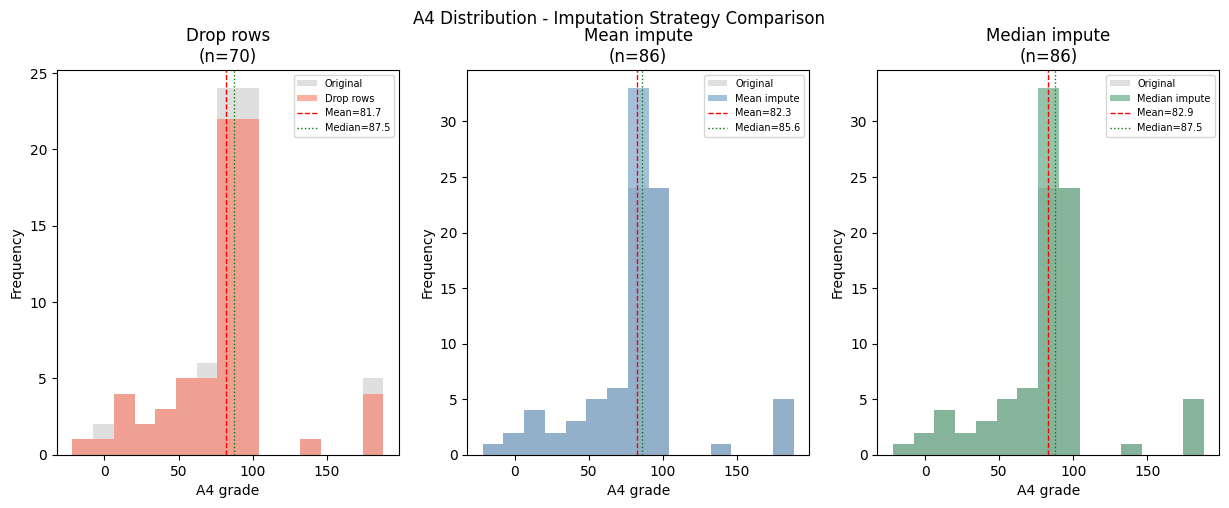

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

configs = [
    (df_drop[col1].dropna(),  f'Drop rows\n(n={len(df_drop[col1].dropna())})',  'tomato'),
    (df_mean[col1],           f'Mean impute\n(n={len(df_mean)})',               'steelblue'),
    (df_median[col1],         f'Median impute\n(n={len(df_median)})',           'seagreen'),
]

for ax, (data, title, color) in zip(axes, configs):
    ax.hist(df[col1].dropna(), bins=15, alpha=0.25, color='gray', label='Original')
    ax.hist(data, bins=15, alpha=0.50, color=color, label=title.split('\n')[0])
    ax.axvline(data.mean(),   color='red',   linestyle='--', linewidth=1, label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(), color='green', linestyle=':',  linewidth=1, label=f'Median={data.median():.1f}')
    ax.set_title(title)
    ax.set_xlabel(f'{col1} grade')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)

plt.suptitle(f'{col1} Distribution - Imputation Strategy Comparison', fontsize=12, y=1)
plt.show()

Median imputation is preferred for this dataset.

-  Dropping rows can remove up to some of the data, shrinking an already small dataset significantly
-  The median is not pulled by the extreme values (negatives, >100 grades) that are still in the raw data at this stage
    - The column means are inflated by those outliers, making mean imputation biased
-  Preserves the correlation with Final_Exam better than mean imputation, because the median is closer to the typical student's true score

Filling missing values with a fixed constant (mean or median) reduces column variance, which can slightly weaken correlations.

## Check for Outliers

Grades normally fall in [0, 100]. However, three assignments carry bonus points:
- A2: up to **15 pts**
- A4 up to **5 pts**
- A6 up to **10 pts**

In [43]:
valid_max = {
    'A1': 100, 'A2': 115, 'A3': 100, 'A4': 105,
    'A5': 100, 'A6': 110, 'A7': 100, 'Final_Exam': 100,
}

print("Outlier summary per column (values outside [0, valid_max]):\n")
outlier_user_ids = set()
for col in grade_cols[:-1]:
    vals = df[col]
    n_over = (vals > valid_max[col]).sum()
    n_neg  = (vals < 0).sum()
    if n_over > 0 or n_neg > 0:
        over_ids = df.loc[vals > valid_max[col], 'user_id'].tolist()
        neg_ids  = df.loc[vals < 0,              'user_id'].tolist()
        print(f"  {col}  (max={valid_max[col]:3d}):  {n_over} above max {over_ids}")
        if n_neg:
            print(f"          {n_neg} negative {neg_ids}")
        outlier_user_ids.update(over_ids + neg_ids)

print(f"\nTotal rows with at least one outlier value: {len(outlier_user_ids)}")

Outlier summary per column (values outside [0, valid_max]):

  A1  (max=100):  5 above max ['U008', 'U010', 'U016', 'U017', 'U025']
          1 negative ['U045']
  A2  (max=115):  1 above max ['U045']
          1 negative ['U083']
  A3  (max=100):  3 above max ['U017', 'U055', 'U067']
          4 negative ['U010', 'U013', 'U027', 'U053']
  A4  (max=105):  6 above max ['U007', 'U025', 'U029', 'U031', 'U037', 'U083']
          1 negative ['U068']
  A5  (max=100):  5 above max ['U057', 'U061', 'U062', 'U063', 'U074']
  A6  (max=110):  2 above max ['U013', 'U046']
          1 negative ['U077']
  A7  (max=100):  7 above max ['U006', 'U015', 'U051', 'U059', 'U069', 'U073', 'U083']

Total rows with at least one outlier value: 30


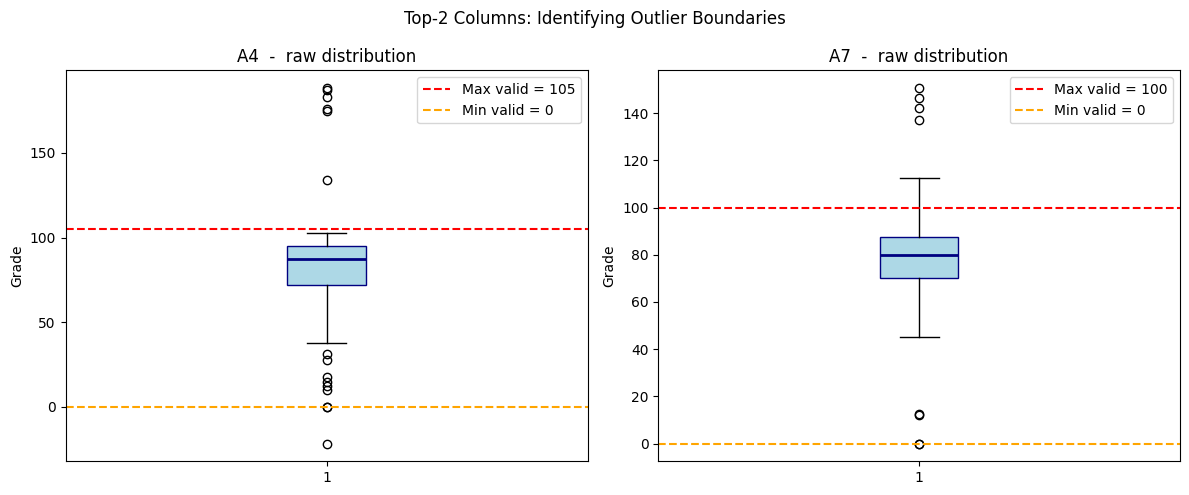

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, [col1, col2]):
    data = df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='navy', linewidth=2))
    ax.axhline(valid_max[col], color='red',    linestyle='--', linewidth=1.5,
               label=f'Max valid = {valid_max[col]}')
    ax.axhline(0,              color='orange', linestyle='--', linewidth=1.5,
               label='Min valid = 0')
    ax.set_title(f'{col}  -  raw distribution')
    ax.set_ylabel('Grade')
    ax.legend()

plt.suptitle('Top-2 Columns: Identifying Outlier Boundaries', fontsize=12)
plt.tight_layout()
plt.show()

Two types of outliers are present:

- Impossible high values
    - when the maximum (with bonus) is 105, or A1 = 174.6 when the max is 100
        - These likely result from data entry errors
-  Negative values
    - Impossible for any graded assignment

In [45]:
def outlier_mask(df, col):
    return df[col].notna() & ((df[col] < 0) | (df[col] > valid_max[col]))

df_opt1 = df[~outlier_mask(df, col1) & ~outlier_mask(df, col2)].copy()

print(f"Option 1 - Remove rows with outliers in {col1} or {col2}")
print(f"  Rows retained : {len(df_opt1)} / {len(df)}")
print(f"  {col1:3s}  mean={df_opt1[col1].mean():.2f}  std={df_opt1[col1].std():.2f}")
print(f"  {col2:3s}  mean={df_opt1[col2].mean():.2f}  std={df_opt1[col2].std():.2f}")
print(f"  Corr {col1}-Final_Exam : {df_opt1[[col1,'Final_Exam']].corr().iloc[0,1]:.3f}")
print(f"  Corr {col2}-Final_Exam : {df_opt1[[col2,'Final_Exam']].corr().iloc[0,1]:.3f}")

Option 1 - Remove rows with outliers in A4 or A7
  Rows retained : 73 / 86
  A4   mean=76.32  std=27.09
  A7   mean=72.07  std=21.49
  Corr A4-Final_Exam : 0.528
  Corr A7-Final_Exam : 0.289


In [46]:
df_opt2 = df.copy()
for col in [col1, col2]:
    df_opt2[col] = df_opt2[col].clip(lower=0, upper=valid_max[col])

print(f"Option 2 - Clip to [0, valid_max] for {col1} and {col2}")
print(f"  Rows retained : {len(df_opt2)} / {len(df)}")
print(f"  {col1:3s}  mean={df_opt2[col1].mean():.2f}  std={df_opt2[col1].std():.2f}")
print(f"  {col2:3s}  mean={df_opt2[col2].mean():.2f}  std={df_opt2[col2].std():.2f}")
print(f"  Corr {col1}-Final_Exam : {df_opt2[[col1,'Final_Exam']].dropna().corr().iloc[0,1]:.3f}")
print(f"  Corr {col2}-Final_Exam : {df_opt2[[col2,'Final_Exam']].dropna().corr().iloc[0,1]:.3f}")

Option 2 - Clip to [0, valid_max] for A4 and A7
  Rows retained : 86 / 86
  A4   mean=77.25  std=28.33
  A7   mean=75.38  std=21.41
  Corr A4-Final_Exam : 0.480
  Corr A7-Final_Exam : 0.347


In [47]:
df_opt3 = df.copy()

for col in [col1, col2]:
    clean_vals = df_opt3.loc[
        df_opt3[col].notna() & (df_opt3[col] >= 0) & (df_opt3[col] <= valid_max[col]), col
    ]
    col_median = clean_vals.median()
    mask = outlier_mask(df_opt3, col)
    df_opt3.loc[mask, col] = col_median
    print(f"  {col}: replaced {mask.sum()} outliers → median {col_median:.2f}")

print(f"\nOption 3 - Replace outliers with column median")
print(f"  Rows retained : {len(df_opt3)} / {len(df)}")
print(f"  {col1:3s}  mean={df_opt3[col1].mean():.2f}  std={df_opt3[col1].std():.2f}")
print(f"  {col2:3s}  mean={df_opt3[col2].mean():.2f}  std={df_opt3[col2].std():.2f}")
print(f"  Corr {col1}-Final_Exam : {df_opt3[[col1,'Final_Exam']].dropna().corr().iloc[0,1]:.3f}")
print(f"  Corr {col2}-Final_Exam : {df_opt3[[col2,'Final_Exam']].dropna().corr().iloc[0,1]:.3f}")

  A4: replaced 7 outliers → median 86.85
  A7: replaced 7 outliers → median 78.80

Option 3 - Replace outliers with column median
  Rows retained : 86 / 86
  A4   mean=76.97  std=25.92
  A7   mean=73.43  std=19.98
  Corr A4-Final_Exam : 0.537
  Corr A7-Final_Exam : 0.290


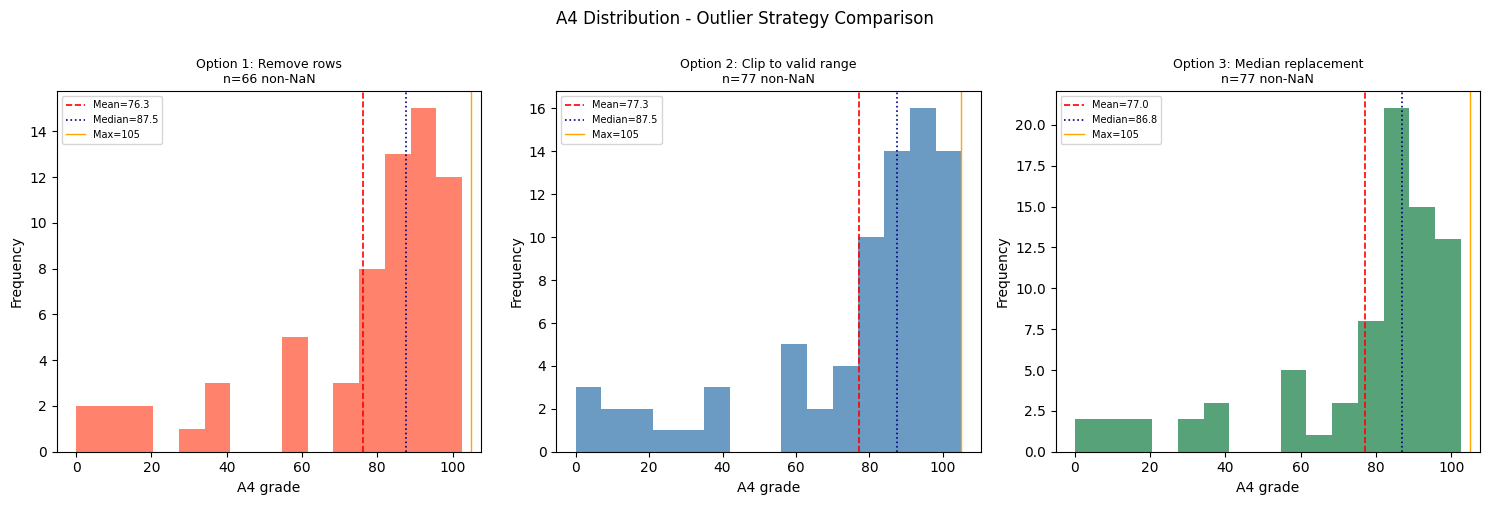

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

options = [
    (df_opt1, 'Option 1: Remove rows',         'tomato'),
    (df_opt2, 'Option 2: Clip to valid range',  'steelblue'),
    (df_opt3, 'Option 3: Median replacement',   'seagreen'),
]

for ax, (dataset, title, color) in zip(axes, options):
    data = dataset[col1].dropna()
    ax.hist(data, bins=15, color=color, alpha=0.8)
    ax.axvline(data.mean(),   color='red',   linestyle='--', linewidth=1.2,
               label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(), color='navy',  linestyle=':',  linewidth=1.2,
               label=f'Median={data.median():.1f}')
    ax.axvline(valid_max[col1], color='orange', linestyle='-', linewidth=1,
               label=f'Max={valid_max[col1]}')
    ax.set_title(f'{title}\nn={len(data)} non-NaN', fontsize=9)
    ax.set_xlabel(f'{col1} grade')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)

plt.suptitle(f'{col1} Distribution - Outlier Strategy Comparison', fontsize=12, y=1)
plt.tight_layout()
plt.show()

Clipping is the preferred strategy for this dataset.

-  All 86 rows are retained, unlike row removal which shrinks the dataset
-  Capping a grade at the assignment maximum is a meaningful fix
    - An entry of 188 is almost certainly the true maximum score entered as raw points
        - Clipping it to 105 is a principled correction
-  Replacing every outlier with the same median collapses them all to one value, artificially reducing variability in the column

---

The operations for a fully clean dataset is:
- Clip outliers first (to [0, valid_max] per column)
    - This ensures that the mean / median computed for imputation is not biased by extreme values
- Median-impute missing values on the clipped data

Applying these two steps in this order yields a dataset that is complete, within valid bounds, and whose distributions are as close as possible to the true underlying grades.